# Milestone 3 Notebook — MiDaS Project

**Canvas Project Number:** #77  
**Group Members:** Emily Chen, Cindy Ren, Alice Wang  
**Course / Milestone:** Milestone 3

This notebook is organized to match the milestone requirements:
1. Problem statement refinement and introduction  
2. Comprehensive EDA review  
3. Baseline model selection and justification  
4. Results interpretation and analysis  
5. Final model pipeline setup

## 0. Brief recap of Milestone 2 progress

**Draft recap**

In Milestone 2, we established the foundation for our project by defining a clear problem setting and conducting exploratory analysis on the MiDaS-60 dataset. Our goal is to compare the performance and representation learning of Vision Transformers (ViTs) and Convolutional Neural Networks (CNNs) in a structured, non-natural image domain (Minecraft).

We first introduced the dataset and verified its structure, confirming a balanced class distribution (60 classes with equal samples) and a predefined *train/test* split. Through visual inspection and metadata analysis, we observed that while block classes are defined by consistent local texture and geometry, the dataset contains substantial variability in global context, including biome type and lighting conditions (day vs. night). Importantly, these contextual factors are unevenly distributed and often correlated with specific classes, suggesting a risk that models may rely on spurious background cues rather than intrinsic object features.

Our exploratory data analysis (EDA) further examined pixel-level statistics and metadata distributions. These analyses highlighted that global brightness and environmental context vary significantly across samples, while intra-class visual patterns remain stable. Based on these findings, we concluded that block classification, rather than biome classification—is a more appropriate task for evaluating model architectures, as it requires robustness to contextual variation and emphasizes fine-grained visual features.

Guided by these insights, we designed a preprocessing pipeline that includes normalization (to reduce lighting variation) and carefully controlled data augmentation (e.g., slight cropping, flipping, and mild color jitter). These transformations aim to improve model robustness without distorting the structured patterns inherent in Minecraft blocks.

Overall, Milestone 2 clarified the challenges posed by the dataset and informed our modeling strategy. In particular, it highlighted the importance of disentangling local texture features from global contextual signals, which motivates our comparison between CNNs (local feature bias) and ViTs (global attention mechanisms) in subsequent modeling steps.

## 1. Problem statement refinement and introduction

### Project introduction

This project focuses on image-based classification using the MiDaS-60 dataset, which consists of Minecraft images labeled by block type. Our objective is to evaluate how well computer vision models can distinguish between visually similar categories in a structured, non-natural image domain. In particular, we aim to understand how different modeling choices interact with the dataset’s visual characteristics, including texture consistency and contextual variability.

### Refined research question

**Primary question:** Can a Vision Transformer outperform a Convolutional Neural Network for Minecraft block classification, and do interpretability methods (Attention Rollout vs. Grad-CAM) reveal meaningful differences in the visual representations learned by the two architectures in a non-natural image domain?

### Why this question matters

A well-defined problem is critical because the dataset contains significant contextual variation, such as biome differences and lighting conditions, that are not directly tied to the target labels. Our EDA shows that block-level labels correspond more closely to stable local visual patterns (e.g., texture and structure), whereas higher-level labels (such as biome) are less consistently reflected in the image content. Framing the problem at the block level reduces reliance on spurious background cues, improves interpretability, and leads to more meaningful evaluation of model performance and generalization


## 2. Environment setup

Run **all cells in this section first**, regardless of whether you are on
Google Colab or a local machine. They:

1. Detect the environment and mount Google Drive (Colab only)
2. Configure all path variables, including the dataset tar location
3. Install / import all required packages
4. Seed random number generators and select the compute device
5. **(Colab only)** Copy the dataset tar from Drive to local scratch and extract it

After running §2, `RAW_TRAIN_DIR` and `RAW_TEST_DIR` are guaranteed to exist
and point to the extracted raw images.


In [1]:
# ==== 2A. Environment detection ====
import sys, os

ON_COLAB = 'google.colab' in sys.modules or 'COLAB_GPU' in os.environ
print('Running on:', 'Google Colab' if ON_COLAB else 'Local machine')

Running on: Local machine


In [2]:
# ==== 2B. Mount Google Drive (Colab only) ====
if ON_COLAB:
    from google.colab import drive
    drive.mount('/content/drive')
    print('Drive mounted.')
else:
    print('Skipped — not on Colab.')

Skipped — not on Colab.


In [12]:
# ==== 2C. Path configuration ====

if ON_COLAB:
    DRIVE_ROOT       = '/content/drive/MyDrive/APcomp209'
    DRIVE_CACHE_ROOT = DRIVE_ROOT
    LOCAL_WORK_ROOT  = '/content'
    CHECKPOINT_DIR   = os.path.join(DRIVE_ROOT, 'ms3_checkpoints')
else:
    LOCAL_WORK_ROOT  = 'data'
    DRIVE_CACHE_ROOT = LOCAL_WORK_ROOT
    CHECKPOINT_DIR   = os.path.join(LOCAL_WORK_ROOT, 'ms3_checkpoints')

# ── Dataset variant ──────────────────────────────────────────────────────────
DATASET_NAME = 'MiDaS-60_small'   # 'MiDaS-60_large' for the full dataset

# ── Tar file config (Colab: tar lives on Drive, is copied & extracted each session) ─
TAR_NAME   = f'{DATASET_NAME}.tar'                         # filename on Drive
DRIVE_TAR  = os.path.join(DRIVE_ROOT if ON_COLAB else LOCAL_WORK_ROOT, TAR_NAME)
LOCAL_TAR  = os.path.join(LOCAL_WORK_ROOT, TAR_NAME)      # /content/ scratch copy
EXTRACT_TO = os.path.join(LOCAL_WORK_ROOT, 'MiDaS_raw')  # extraction target

# RAW_TRAIN_DIR / RAW_TEST_DIR are set in §2F after extraction (Colab)
# or resolved directly from LOCAL_WORK_ROOT (local machine).

os.makedirs(CHECKPOINT_DIR, exist_ok=True)

# Results directory — EDA figures are saved here instead of displayed inline
RESULTS_EDA_DIR = os.path.join(
    DRIVE_ROOT if ON_COLAB else '.', 'results', 'eda'
)
os.makedirs(RESULTS_EDA_DIR, exist_ok=True)

print(f'ON_COLAB        : {ON_COLAB}')
print(f'TAR_NAME        : {TAR_NAME}')
print(f'DRIVE_TAR       : {DRIVE_TAR}')
print(f'LOCAL_TAR       : {LOCAL_TAR}')
print(f'EXTRACT_TO      : {EXTRACT_TO}')
print(f'CHECKPOINT_DIR  : {CHECKPOINT_DIR}')
print(f'RESULTS_EDA_DIR : {RESULTS_EDA_DIR}')


RAW_TRAIN_DIR : data/MiDaS-60_small/train  (exists: True)
RAW_TEST_DIR  : data/MiDaS-60_small/test   (exists: True)
CHECKPOINT_DIR: data/ms3_checkpoints


In [8]:
# ==== 2D. Imports ====
import random, time, copy, subprocess, shutil, tarfile
from pathlib import Path
from collections import Counter
from itertools import combinations

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from tqdm.auto import tqdm

import torch
from torch import nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms, models
from skimage.metrics import structural_similarity as ssim_fn

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score


In [9]:
# ==== 2E. Seeds & device ====
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Device:', device)

Device: cpu


In [ ]:
# ==== 2F. Copy & extract dataset tar, set raw data paths ====
# Colab: /content is wiped each session — copy tar from Drive and extract.
# Local: data is assumed to already be present; copy/extract is skipped.

if ON_COLAB:
    # ── Step 1: copy tar to /content local scratch ───────────────────────────
    if not os.path.exists(LOCAL_TAR):
        print(f'Copying {TAR_NAME} from Drive → /content ...')
        shutil.copy2(DRIVE_TAR, LOCAL_TAR)
        size_mb = os.path.getsize(LOCAL_TAR) / 1e6
        print(f'  Done ({size_mb:.0f} MB)')
    else:
        print(f'Tar already in /content — skipping copy.')

    # ── Step 2: extract tar into EXTRACT_TO ──────────────────────────────────
    os.makedirs(EXTRACT_TO, exist_ok=True)
    extracted = [d for d in os.listdir(EXTRACT_TO)
                 if os.path.isdir(os.path.join(EXTRACT_TO, d))]

    if not extracted:
        print(f'Extracting {TAR_NAME} → {EXTRACT_TO} ...')
        with tarfile.open(LOCAL_TAR) as tar:
            tar.extractall(EXTRACT_TO)
        extracted = [d for d in os.listdir(EXTRACT_TO)
                     if os.path.isdir(os.path.join(EXTRACT_TO, d))]
        print('  Extraction complete.')
    else:
        print(f'Already extracted — skipping. (found: {extracted})')

    # auto-detect top-level directory inside the archive
    RAW_DATASET_DIR = os.path.join(EXTRACT_TO, extracted[0])

else:
    # Local machine: data lives directly under LOCAL_WORK_ROOT
    RAW_DATASET_DIR = os.path.join(LOCAL_WORK_ROOT, DATASET_NAME)

RAW_TRAIN_DIR = os.path.join(RAW_DATASET_DIR, 'train')
RAW_TEST_DIR  = os.path.join(RAW_DATASET_DIR, 'test')

print(f'RAW_DATASET_DIR : {RAW_DATASET_DIR}')
print(f'RAW_TRAIN_DIR   : {RAW_TRAIN_DIR}  (exists: {os.path.exists(RAW_TRAIN_DIR)})')
print(f'RAW_TEST_DIR    : {RAW_TEST_DIR}   (exists: {os.path.exists(RAW_TEST_DIR)})')


## 3. Data description

**Dataset:** MiDaS-60  
**Source:** `https://github.com/MinecraftDataset/MiDaS/tree/main.`

### Summary
- The dataset contains labeled images organized into training and test folders.
- Each class corresponds to a visual category in the environment.
- Our current framing emphasizes **block classification**.
- The images appear to vary in texture, color, viewpoint, and scene complexity.

### Why this dataset is useful
This dataset allows us to test whether image features are sufficient for distinguishing meaningful environmental categories and whether label granularity affects modeling success.

### Notes / caveats
- Some classes may be visually similar.
- Class imbalance may affect training and evaluation.
- A biome-level formulation may introduce label noise if multiple visually distinct blocks are merged together.

In [13]:
# ==== 3A. Load raw dataset (EDA / inspection — no augmentation) ====
eda_transform = transforms.ToTensor()

eda_train_ds = datasets.ImageFolder(RAW_TRAIN_DIR, transform=eda_transform)
eda_test_ds  = datasets.ImageFolder(RAW_TEST_DIR,  transform=eda_transform)

class_names = eda_train_ds.classes
num_classes  = len(class_names)

print(f'Train images : {len(eda_train_ds)}')
print(f'Test images  : {len(eda_test_ds)}')
print(f'Classes      : {num_classes}')

Train images : 32400
Test images  : 3600
Classes      : 60


In [14]:
# ==== 3B. Per-class image count table ====
train_counts = Counter([lbl for _, lbl in eda_train_ds.samples])
test_counts  = Counter([lbl for _, lbl in eda_test_ds.samples])

class_df = pd.DataFrame({
    'class_name':  class_names,
    'train_count': [train_counts.get(i, 0) for i in range(num_classes)],
    'test_count':  [test_counts.get(i,  0) for i in range(num_classes)],
})
class_df['total'] = class_df['train_count'] + class_df['test_count']
class_df = class_df.sort_values('total', ascending=False).reset_index(drop=True)

display(class_df)
print('Total images:', class_df['total'].sum())

,class_name,train_count,test_count,total
0,acacia_log,540,60,600
1,acacia_planks,540,60,600
2,jungle_planks,540,60,600
3,lapis_ore,540,60,600
4,lava,540,60,600
5,magma_block,540,60,600
6,melon,540,60,600
7,mossy_cobblestone,540,60,600
8,nether_bricks,540,60,600
9,nether_gold_ore,540,60,600


Total images: 36000


## 4. Comprehensive EDA

### Key questions
- Are classes balanced across train and test?
- What do images in each class actually look like? Are any visually ambiguous?
- Are there near-duplicate images within a split or across train/test (leakage)?
- Do per-class brightness / contrast statistics reveal spurious cues?

### 4A. Per-class image grids

Each grid shows every image in one class, laid out as **10 columns × 6 rows = 60 thumbnails** for the training split, and all images in the test split.
This makes near-identical shots, unusual lighting, or odd viewpoints easy to spot.

In [ ]:
# ==== 4A. Per-class image grids ====
# Creates two combined overview figures and saves them to RESULTS_EDA_DIR.
#   Train : 60 rows (classes) × 9 columns (sample images)  → train_overview_60x9.png
#   Test  : 60 rows (classes) × all-test-images-per-class  → test_overview.png
# Figures are NOT displayed inline (plt.show() is skipped) to avoid flooding
# the notebook output on Colab.

THUMB_OV = (64, 64)   # thumbnail size per cell

def save_combined_grid(split_dir, split_name, class_names,
                       cols, thumb=THUMB_OV, out_path=None):
    """Build one figure with len(class_names) rows × cols columns and save it."""
    n_rows = len(class_names)
    fig, axes = plt.subplots(
        n_rows, cols,
        figsize=(cols * thumb[0] / 72, n_rows * thumb[1] / 72)
    )
    if n_rows == 1:
        axes = [axes]

    for row, cls_name in enumerate(tqdm(class_names,
                                        desc=f'Building {split_name} grid',
                                        leave=False)):
        cls_path  = os.path.join(split_dir, cls_name)
        img_files = sorted(
            f for f in os.listdir(cls_path)
            if f.lower().endswith(('.png', '.jpg', '.jpeg'))
        )[:cols]

        for col, fname in enumerate(img_files):
            with Image.open(os.path.join(cls_path, fname)) as img:
                axes[row][col].imshow(
                    img.convert('RGB').resize(thumb, Image.BILINEAR))
            axes[row][col].axis('off')

        # class label on the left-most cell
        axes[row][0].set_ylabel(cls_name, fontsize=4.5,
                                rotation=0, labelpad=38, va='center')

        for col in range(len(img_files), cols):
            axes[row][col].axis('off')

    fig.suptitle(
        f'{split_name} overview — {n_rows} classes × {cols} samples',
        fontsize=10, y=1.002
    )
    plt.tight_layout()
    fig.savefig(out_path, bbox_inches='tight', dpi=100)
    plt.close(fig)
    print(f'Saved {split_name} grid → {out_path}')


# ── Train: 60 classes × 9 samples ──────────────────────────────────────────
save_combined_grid(
    split_dir   = RAW_TRAIN_DIR,
    split_name  = 'Train',
    class_names = class_names,
    cols        = 9,
    out_path    = os.path.join(RESULTS_EDA_DIR, 'train_overview_60x9.png'),
)

# ── Test: 60 classes × (all test images per class) ─────────────────────────
test_per_class = max(1, len(eda_test_ds) // num_classes)
save_combined_grid(
    split_dir   = RAW_TEST_DIR,
    split_name  = 'Test',
    class_names = class_names,
    cols        = test_per_class,
    out_path    = os.path.join(RESULTS_EDA_DIR, 'test_overview.png'),
)


### 4B. Per-class pixel statistics

Mean brightness and pixel standard deviation per class reveal lighting or
contrast biases that could act as spurious classification cues.

In [ ]:
# ==== 4B. Per-class mean brightness & contrast ====
stats = []
for cls_name in tqdm(class_names, desc='Classes'):
    cls_path = os.path.join(RAW_TRAIN_DIR, cls_name)
    means, stds = [], []
    for fname in os.listdir(cls_path):
        if not fname.lower().endswith(('.png', '.jpg', '.jpeg')):
            continue
        with Image.open(os.path.join(cls_path, fname)) as img:
            arr = np.array(img.convert('RGB'), dtype=np.float32) / 255.0
            means.append(arr.mean())
            stds.append(arr.std())
    stats.append({'class': cls_name,
                  'mean_brightness': np.mean(means),
                  'mean_std': np.mean(stds)})

stats_df = pd.DataFrame(stats).sort_values('mean_brightness')

fig, axes = plt.subplots(1, 2, figsize=(16, max(5, num_classes * 0.22)))
axes[0].barh(stats_df['class'], stats_df['mean_brightness'])
axes[0].set_xlabel('Mean brightness (0-1)')
axes[0].set_title('Per-class mean pixel brightness (train)')
axes[1].barh(stats_df['class'], stats_df['mean_std'])
axes[1].set_xlabel('Mean pixel std (0-1)')
axes[1].set_title('Per-class pixel contrast (train)')
plt.tight_layout()
plt.show()

### 4C. Similarity & data-leakage analysis

We measure pairwise similarity with three complementary metrics:

| Metric | Captures | Near-dup threshold |
|---|---|---|
| **SSIM** | Structure, luminance, contrast | ≥ 0.90 |
| **Histogram correlation** | Global colour distribution | ≥ 0.97 |
| **Feature cosine sim** | Perceptual content (ResNet-18 pool) | ≥ 0.98 |

We check:
1. **Intra-split** — near-duplicates within train or within test (redundancy)
2. **Cross-split** — images that appear in both train and test (**leakage risk**)

In [ ]:
# ==== 4C-0. Shared helpers for similarity computation ====

# ── Feature extractor (ResNet-18 backbone, no classifier head) ──────────────
_feat_model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)
_feat_model.fc = nn.Identity()
_feat_model.eval()
_feat_model = _feat_model.to(device)          # use GPU when available

_feat_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

def extract_features(paths, batch_size=64):
    """Batched GPU feature extraction; returns CPU tensor (N, 512)."""
    tensors = []
    for p in paths:
        with Image.open(p) as img:
            tensors.append(_feat_transform(img.convert('RGB')))
    all_feats = []
    with torch.no_grad():
        for i in range(0, len(tensors), batch_size):
            batch = torch.stack(tensors[i:i + batch_size]).to(device)
            all_feats.append(_feat_model(batch).cpu())
    return torch.cat(all_feats)

def load_gray(path, size=(128, 128)):
    with Image.open(path) as img:
        return np.array(img.convert('L').resize(size, Image.BILINEAR))

def load_rgb(path, size=(128, 128)):
    with Image.open(path) as img:
        return np.array(img.convert('RGB').resize(size, Image.BILINEAR))

def hist_corr(a, b):
    corrs = []
    for c in range(3):
        h1 = np.histogram(a[:, :, c], bins=64, range=(0, 255))[0].astype(float)
        h2 = np.histogram(b[:, :, c], bins=64, range=(0, 255))[0].astype(float)
        h1 /= h1.sum() + 1e-9; h2 /= h2.sum() + 1e-9
        corrs.append(float(np.corrcoef(h1, h2)[0, 1]))
    return float(np.mean(corrs))

def feat_cos(a, b):
    return float(nn.functional.cosine_similarity(a.unsqueeze(0), b.unsqueeze(0)))

SSIM_T, HIST_T, FEAT_T = 0.90, 0.97, 0.98

# ── Intra-split near-duplicate scan ─────────────────────────────────────────
def intra_split_scan(split_dir, split_tag, top_k_show=3):
    """
    Scan every class in split_dir for near-duplicate pairs.
    Flags pairs that simultaneously exceed SSIM_T, HIST_T, and FEAT_T.
    Pair visualisations are saved to RESULTS_EDA_DIR (not shown inline).
    Returns a list of flagged (class, img_A, img_B, SSIM, Hist, Feat) tuples.
    """
    all_flagged = []

    for cls_name in tqdm(class_names, desc=f'Intra-split scan [{split_tag}]'):
        cls_path  = os.path.join(split_dir, cls_name)
        img_files = sorted(
            f for f in os.listdir(cls_path)
            if f.lower().endswith(('.png', '.jpg', '.jpeg'))
        )
        paths = [os.path.join(cls_path, f) for f in img_files]

        feats = extract_features(paths)
        grays = [load_gray(p) for p in paths]
        rgbs  = [load_rgb(p)  for p in paths]

        pairs = []
        for i, j in combinations(range(len(paths)), 2):
            s = ssim_fn(grays[i], grays[j], data_range=255)
            h = hist_corr(rgbs[i], rgbs[j])
            c = feat_cos(feats[i], feats[j])
            pairs.append((s, h, c, i, j))
        pairs.sort(key=lambda x: x[0] + x[1] + x[2], reverse=True)

        for s, h, c, i, j in pairs:
            if s >= SSIM_T and h >= HIST_T and c >= FEAT_T:
                all_flagged.append((cls_name, img_files[i], img_files[j], s, h, c))

        # save top-K pair figures
        top = pairs[:top_k_show]
        if not top:
            continue
        fig, axes = plt.subplots(len(top), 2, figsize=(5, len(top) * 2.2))
        if len(top) == 1:
            axes = [axes]
        fig.suptitle(f'[{split_tag}] {cls_name} — top {len(top)} pairs', fontsize=9)
        for row, (s, h, c, i, j) in enumerate(top):
            for col, idx in enumerate([i, j]):
                with Image.open(paths[idx]) as img:
                    axes[row][col].imshow(img.convert('RGB'))
                axes[row][col].axis('off')
                axes[row][col].set_title(img_files[idx][:18], fontsize=6)
            axes[row][0].set_ylabel(
                f'SSIM={s:.2f}  Hist={h:.2f}\nFeat={c:.2f}', fontsize=6)
        plt.tight_layout()
        fig.savefig(
            os.path.join(RESULTS_EDA_DIR,
                         f'intra_{split_tag}_{cls_name}_top{top_k_show}.png'),
            bbox_inches='tight', dpi=80
        )
        plt.close(fig)

    if all_flagged:
        flag_df = pd.DataFrame(all_flagged,
            columns=['class', 'img_A', 'img_B', 'SSIM', 'Hist', 'Feat'])
        print(f'\n  {len(flag_df)} near-duplicate pair(s) flagged in [{split_tag}]:')
        display(flag_df)
    else:
        print(f'\n  No near-duplicates in [{split_tag}] '
              f'(SSIM>={SSIM_T}, Hist>={HIST_T}, Feat>={FEAT_T})')
    return all_flagged

print(f'Similarity helpers ready.  Feature model on: '
      f'{next(_feat_model.parameters()).device}')


In [ ]:
# ==== 4C-1a. Intra-split near-duplicate scan — TRAIN ====
flagged_train = intra_split_scan(RAW_TRAIN_DIR, 'train')


In [ ]:
# ==== 4C-1b. Intra-split near-duplicate scan — TEST ====
flagged_test = intra_split_scan(RAW_TEST_DIR, 'test')


In [ ]:
# ==== 4C-2. Cross-split leakage scan (train vs test) ====
# Uses feature cosine similarity only — fast batched matrix multiply on GPU.

leakage = []

for cls_name in tqdm(class_names, desc='Cross-split leakage'):
    tr_path = os.path.join(RAW_TRAIN_DIR, cls_name)
    te_path = os.path.join(RAW_TEST_DIR,  cls_name)

    tr_files = sorted(f for f in os.listdir(tr_path)
                      if f.lower().endswith(('.png', '.jpg', '.jpeg')))
    te_files = sorted(f for f in os.listdir(te_path)
                      if f.lower().endswith(('.png', '.jpg', '.jpeg')))

    tr_feats = extract_features([os.path.join(tr_path, f) for f in tr_files])
    te_feats = extract_features([os.path.join(te_path, f) for f in te_files])

    # cosine similarity matrix (n_tr × n_te) — computed on GPU
    tr_n = nn.functional.normalize(tr_feats, dim=1).to(device)
    te_n = nn.functional.normalize(te_feats, dim=1).to(device)
    sim  = (tr_n @ te_n.T).cpu().numpy()

    for i in range(sim.shape[0]):
        for j in range(sim.shape[1]):
            if sim[i, j] >= FEAT_T:
                leakage.append((cls_name, tr_files[i], te_files[j],
                                float(sim[i, j])))

if leakage:
    leak_df = pd.DataFrame(leakage,
        columns=['class', 'train_img', 'test_img', 'feat_cos'])
    print(f'  {len(leak_df)} potential leakage pair(s) found:')
    display(leak_df)

    # heatmap for worst-offending class
    worst_cls = leak_df.groupby('class').size().idxmax()
    tr_path = os.path.join(RAW_TRAIN_DIR, worst_cls)
    te_path = os.path.join(RAW_TEST_DIR,  worst_cls)
    tr_files = sorted(f for f in os.listdir(tr_path)
                      if f.lower().endswith(('.png', '.jpg', '.jpeg')))
    te_files = sorted(f for f in os.listdir(te_path)
                      if f.lower().endswith(('.png', '.jpg', '.jpeg')))
    tr_f = extract_features([os.path.join(tr_path, f) for f in tr_files])
    te_f = extract_features([os.path.join(te_path, f) for f in te_files])
    tr_n  = nn.functional.normalize(tr_f, dim=1).to(device)
    te_n  = nn.functional.normalize(te_f, dim=1).to(device)
    sim   = (tr_n @ te_n.T).cpu().numpy()

    plt.figure(figsize=(min(14, len(te_files) * 0.4 + 2),
                        min(10, len(tr_files) * 0.4 + 2)))
    sns.heatmap(sim, xticklabels=te_files, yticklabels=tr_files,
                cmap='YlOrRd', vmin=0.8, vmax=1.0,
                cbar_kws={'label': 'cosine similarity'})
    plt.title(f"Train × Test similarity — class '{worst_cls}'")
    plt.xlabel('Test images'); plt.ylabel('Train images')
    plt.xticks(fontsize=5, rotation=90); plt.yticks(fontsize=5)
    plt.tight_layout()
    heatmap_path = os.path.join(RESULTS_EDA_DIR,
                                f'leakage_heatmap_{worst_cls}.png')
    plt.savefig(heatmap_path, bbox_inches='tight', dpi=100)
    plt.close()
    print(f'Heatmap saved → {heatmap_path}')
else:
    print(f'  No cross-split leakage (feature cosine threshold: {FEAT_T})')


## 5. Feature engineering & preprocessing

### Design rationale

Our EDA (§4) revealed two key properties that guide preprocessing:

1. **Consistent local texture, variable global context** — blocks have stable texture patterns but appear under different lighting and biome backgrounds. We want transforms that *preserve* local texture while reducing sensitivity to global context.

2. **No data leakage** (verified in §4C) — we can use the full predefined train split without risk of inflated test accuracy.

### Chosen transforms

| Stage | Transform | Reason |
|---|---|---|
| Resize | `224 × 224` (cached) | Required by ResNet-18 / ViT; standardises viewing distance |
| Flip | `RandomHorizontalFlip(p=0.5)` | Blocks are symmetric; doubles effective dataset size |
| Color jitter | `ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1)` | Reduces sensitivity to biome lighting |
| Normalize | ImageNet mean/std | Required for pretrained weights to generalise |

We deliberately **omit** rotation (Minecraft blocks are always axis-aligned) and strong random crops (they would destroy the local texture pattern that distinguishes classes).

### Caching strategy

Resizing to 224 × 224 is the only slow preprocessing step. We do it once, save the result to Drive (Colab) or a local folder, and load the cached images every subsequent session. Only the lightweight augmentations (flip, jitter, normalize) are applied on-the-fly during training.

### 5A. Build or load the preprocessed cache

In [ ]:
# ==== 5A. Build or load the preprocessed (resized) cache ====
# §2F already copied and extracted the tar; this cell only builds the
# 224×224 resize cache (written once to /content on Colab, or locally).
# Subsequent runs skip straight to loading the cached directories.

# ── Config ──────────────────────────────────────────────────────────────────
IMG_SIZE      = (224, 224)
SAVE_FORMAT   = 'PNG'
CACHE_VERSION = 'v1'          # bump to force a full rebuild

_tag             = f'MiDaS_{IMG_SIZE[0]}_{CACHE_VERSION}'
CACHE_LOCAL_DIR  = os.path.join(LOCAL_WORK_ROOT, _tag, DATASET_NAME)
SENTINEL         = os.path.join(LOCAL_WORK_ROOT, _tag, '.cache_ok')

# ── Build function ───────────────────────────────────────────────────────────
def _build_cache(src_root, dst_root, img_size, fmt):
    ext = '.png' if fmt.upper() == 'PNG' else '.jpg'
    for split in ['train', 'test']:
        classes = sorted(
            d for d in os.listdir(os.path.join(src_root, split))
            if os.path.isdir(os.path.join(src_root, split, d))
        )
        for cls in tqdm(classes, desc=f'  Caching {split}'):
            dst_cls = os.path.join(dst_root, split, cls)
            os.makedirs(dst_cls, exist_ok=True)
            for fname in os.listdir(os.path.join(src_root, split, cls)):
                src_p = os.path.join(src_root, split, cls, fname)
                dst_p = os.path.join(dst_cls, Path(fname).stem + ext)
                if os.path.exists(dst_p):
                    continue
                try:
                    with Image.open(src_p) as img:
                        img = img.convert('RGB').resize(img_size, Image.BILINEAR)
                        kw  = {} if fmt.upper() == 'PNG' else {'quality': 95}
                        img.save(dst_p, format=fmt.upper(), **kw)
                except Exception as e:
                    print(f'  skip {src_p}: {e}')
    open(SENTINEL, 'w').close()

# ── Run or skip ──────────────────────────────────────────────────────────────
if not os.path.exists(SENTINEL):
    print('Building resized cache (one-time) ...')
    os.makedirs(CACHE_LOCAL_DIR, exist_ok=True)
    _build_cache(RAW_DATASET_DIR, CACHE_LOCAL_DIR, IMG_SIZE, SAVE_FORMAT)
    print('Cache built.')
else:
    print('Resized cache already exists — skipping.')

CACHED_TRAIN_DIR = os.path.join(CACHE_LOCAL_DIR, 'train')
CACHED_TEST_DIR  = os.path.join(CACHE_LOCAL_DIR, 'test')
print(f'CACHED_TRAIN_DIR : {CACHED_TRAIN_DIR}  (exists: {os.path.exists(CACHED_TRAIN_DIR)})')
print(f'CACHED_TEST_DIR  : {CACHED_TEST_DIR}   (exists: {os.path.exists(CACHED_TEST_DIR)})')


### 5B. Transform definitions & augmentation examples

In [ ]:
# ==== 5B-i. Define transforms ====

train_transform = transforms.Compose([
    # images are already 224x224 in the cache — no Resize needed
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(brightness=0.2, contrast=0.2,
                           saturation=0.1, hue=0.0),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

eval_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std =[0.229, 0.224, 0.225]),
])

print('train_transform:\n', train_transform)
print()
print('eval_transform:\n',  eval_transform)

In [ ]:
# ==== 5B-ii. Visualise augmentation examples ====
# Shows original + 5 augmented versions for a random sample of classes.

N_CLASSES_SHOW = 6
N_AUG          = 5

to_pil = transforms.ToPILImage()
unnorm = transforms.Compose([
    transforms.Normalize(mean=[0, 0, 0],
                         std=[1/0.229, 1/0.224, 1/0.225]),
    transforms.Normalize(mean=[-0.485, -0.456, -0.406],
                         std=[1, 1, 1]),
])

sampled_classes = random.sample(class_names, N_CLASSES_SHOW)

fig, axes = plt.subplots(N_CLASSES_SHOW, N_AUG + 1,
                          figsize=((N_AUG + 1) * 2.2, N_CLASSES_SHOW * 2.2))
fig.suptitle('Original  |  Augmented versions (train_transform)', fontsize=10)

for row, cls_name in enumerate(sampled_classes):
    cls_path  = os.path.join(CACHED_TRAIN_DIR, cls_name)
    img_file  = random.choice(os.listdir(cls_path))
    orig_path = os.path.join(cls_path, img_file)

    with Image.open(orig_path) as img:
        orig = img.convert('RGB')

    axes[row][0].imshow(orig)
    axes[row][0].axis('off')
    axes[row][0].set_ylabel(cls_name, fontsize=7)
    if row == 0:
        axes[row][0].set_title('original', fontsize=7)

    for col in range(1, N_AUG + 1):
        aug = to_pil(unnorm(train_transform(orig)).clamp(0, 1))
        axes[row][col].imshow(aug)
        axes[row][col].axis('off')
        if row == 0:
            axes[row][col].set_title(f'aug {col}', fontsize=7)

plt.tight_layout()
plt.show()

### 5C. Dataset splits & DataLoaders

In [ ]:
# ==== 5C. Build datasets & DataLoaders ====

full_train_ds = datasets.ImageFolder(CACHED_TRAIN_DIR, transform=train_transform)
test_ds       = datasets.ImageFolder(CACHED_TEST_DIR,  transform=eval_transform)

assert full_train_ds.classes == class_names, 'Class list mismatch — check cache.'

# 80/20 train/val split with fixed seed
train_size = int(0.8 * len(full_train_ds))
val_size   = len(full_train_ds) - train_size

train_ds, val_ds = random_split(
    full_train_ds,
    [train_size, val_size],
    generator=torch.Generator().manual_seed(SEED),
)

# val split must use eval_transform (no augmentation)
val_ds.dataset        = copy.copy(full_train_ds)
val_ds.dataset.transform = eval_transform

print(f'Train : {len(train_ds):>5} images')
print(f'Val   : {len(val_ds):>5} images')
print(f'Test  : {len(test_ds):>5} images')
print(f'Classes: {num_classes}')

_workers = 4 if ON_COLAB else min(4, os.cpu_count() or 1)

train_loader = DataLoader(
    train_ds, batch_size=64, shuffle=True,
    num_workers=_workers, pin_memory=True,
    persistent_workers=(_workers > 0),
)
val_loader = DataLoader(
    val_ds, batch_size=64, shuffle=False,
    num_workers=_workers, pin_memory=True,
    persistent_workers=(_workers > 0),
)
test_loader = DataLoader(
    test_ds, batch_size=64, shuffle=False,
    num_workers=_workers, pin_memory=True,
    persistent_workers=(_workers > 0),
)

print(f'\nTrain batches : {len(train_loader)}')
print(f'Val   batches : {len(val_loader)}')
print(f'Test  batches : {len(test_loader)}')

# sanity check
_imgs, _lbls = next(iter(train_loader))
print(f'Batch tensor  : {_imgs.shape}  min={_imgs.min():.2f}  max={_imgs.max():.2f}')

## 6. Baseline model selection and justification

### Baseline choice
A simple but relevant baseline for image classification is a small CNN or a transfer-learning model such as ResNet18. This type of model is more appropriate than linear or logistic regression alone because the task depends heavily on spatial image structure.

### Justification
- **Simple enough** to train and explain
- **Relevant** for image data
- **Interpretable enough** at the level of confusion matrices and class-wise performance
- Serves as a practical benchmark before trying more advanced architectures

#### Build ResNet-18 model

In [10]:
model = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

# replace final fully connected layer
model.fc = nn.Linear(model.fc.in_features, num_classes)

model = model.to(device)
print(model)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 211MB/s]

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

#### Fine-tuning setup

We use **partial fine-tuning**: freeze early layers and train only `layer4` and the final `fc` layer. This keeps training efficient while still allowing the model to adapt high-level visual features to the MiDaS dataset.


In [11]:
# freeze earlier layers
for param in model.parameters():
    param.requires_grad = False

# unfreeze layer4 and fc
for param in model.layer4.parameters():
    param.requires_grad = True

for param in model.fc.parameters():
    param.requires_grad = True

# show how many parameters are trainable
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
total_params = sum(p.numel() for p in model.parameters())
print(f"Trainable params: {trainable_params:,} / {total_params:,}")

Trainable params: 8,424,508 / 11,207,292


In [12]:
# Loss and optimizer
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=1e-4
)

In [15]:
# Training and evaluation functions
def train_one_epoch(model, loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)
        preds = torch.argmax(outputs, dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc


def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)
            preds = torch.argmax(outputs, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(loader.dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)

    return epoch_loss, epoch_acc, all_labels, all_preds

In [29]:
num_epochs = 10

history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": []
}

BEST_MODEL_PATH = os.path.join(CHECKPOINT_DIR, "best_resnet18_ms3_val10_checkpoint.pth")

if os.path.exists(BEST_MODEL_PATH):
    print(f"Found existing checkpoint at: {BEST_MODEL_PATH}")

    checkpoint = torch.load(BEST_MODEL_PATH, map_location=device)
    model.load_state_dict(checkpoint["model_state_dict"])
    history = checkpoint["history"]
    best_val_acc = checkpoint["best_val_acc"]
    trained_epochs = checkpoint["trained_epochs"]

    print(f"Loaded saved best model from {trained_epochs} epoch(s).")
    print(f"Best saved validation accuracy: {best_val_acc:.4f}")

else:
    print("No saved checkpoint found. Start training...")

    best_model_wts = copy.deepcopy(model.state_dict())
    best_val_acc = 0.0

    for epoch in range(num_epochs):
        start_time = time.time()

        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device)
        val_loss, val_acc, _, _ = evaluate(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["val_loss"].append(val_loss)
        history["val_acc"].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_wts = copy.deepcopy(model.state_dict())

            checkpoint = {
                "model_state_dict": best_model_wts,
                "history": history,
                "best_val_acc": best_val_acc,
                "trained_epochs": epoch + 1
            }
            torch.save(checkpoint, BEST_MODEL_PATH)

        elapsed = time.time() - start_time
        print(f"Epoch [{epoch+1}/{num_epochs}] "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f} | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.4f} | "
              f"Time: {elapsed:.1f}s")

    model.load_state_dict(best_model_wts)
    print(f"\nBest Validation Accuracy: {best_val_acc:.4f}")


No saved checkpoint found. Start training...
Epoch [1/10] Train Loss: 0.0087 | Train Acc: 0.9975 | Val Loss: 0.0069 | Val Acc: 0.9986 | Time: 28.1s
Epoch [2/10] Train Loss: 0.0040 | Train Acc: 0.9991 | Val Loss: 0.0017 | Val Acc: 0.9997 | Time: 26.6s
Epoch [3/10] Train Loss: 0.0009 | Train Acc: 0.9999 | Val Loss: 0.0024 | Val Acc: 0.9992 | Time: 26.4s
Epoch [4/10] Train Loss: 0.0026 | Train Acc: 0.9991 | Val Loss: 0.0036 | Val Acc: 0.9986 | Time: 26.5s
Epoch [5/10] Train Loss: 0.0022 | Train Acc: 0.9994 | Val Loss: 0.0024 | Val Acc: 0.9995 | Time: 26.3s
Epoch [6/10] Train Loss: 0.0048 | Train Acc: 0.9990 | Val Loss: 0.0032 | Val Acc: 0.9992 | Time: 26.6s
Epoch [7/10] Train Loss: 0.0040 | Train Acc: 0.9990 | Val Loss: 0.0024 | Val Acc: 0.9992 | Time: 26.5s
Epoch [8/10] Train Loss: 0.0015 | Train Acc: 0.9998 | Val Loss: 0.0081 | Val Acc: 0.9975 | Time: 26.5s
Epoch [9/10] Train Loss: 0.0025 | Train Acc: 0.9992 | Val Loss: 0.0075 | Val Acc: 0.9972 | Time: 26.3s
Epoch [10/10] Train Loss: 0.

## 7. Results interpretation and analysis


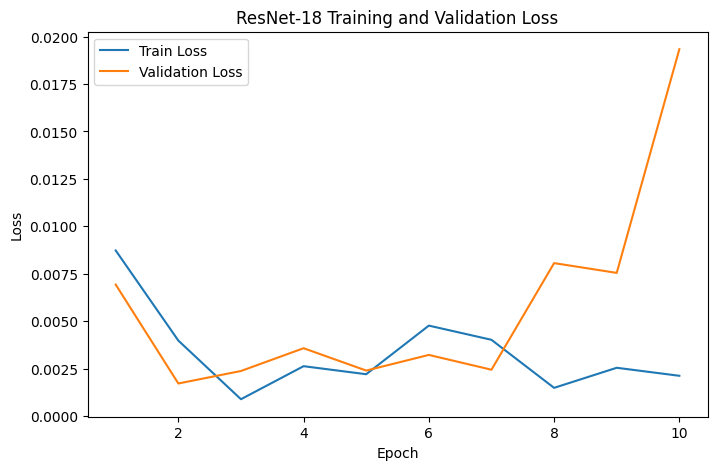

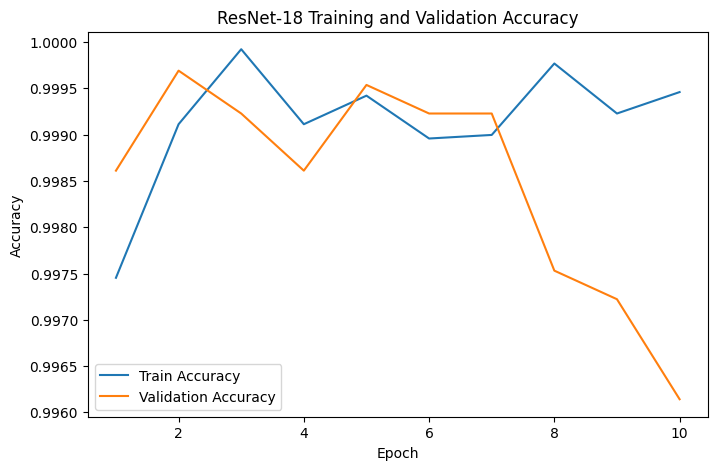

In [30]:
if len(history["train_loss"]) > 0:
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("ResNet-18 Training and Validation Loss")
    plt.legend()
    plt.show()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_acc"], label="Train Accuracy")
    plt.plot(epochs, history["val_acc"], label="Validation Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.title("ResNet-18 Training and Validation Accuracy")
    plt.legend()
    plt.show()
else:
    print("No training history available.")

In [31]:
# Final evaluation on the test set
test_loss, test_acc, y_true, y_pred = evaluate(model, test_loader, criterion, device)

print(f"Final Test Loss: {test_loss:.4f}")
print(f"Final Test Accuracy: {test_acc:.4f}")

Final Test Loss: 0.0375
Final Test Accuracy: 0.9889


## 8. Future directions

## 9. Final model pipeline setup
